# 01 - Basic Sequencing with tProc v2

**Objective:** Learn how to define pulses, create a sequence, acquire data, and understand the basic structure of a tProc v2 program.

## 1. Setup

In [ ]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging

from qick import *
from qick.asm_v2 import AveragerProgramV2

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')
logging.getLogger("qick_processor").setLevel(logging.WARNING)

# Connect to the board (adjust the path to your firmware)
BITSTREAM_PATH = '/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels (adjust based on your firmware)
GEN_CH = 0      # Generator channel 0
RO_CH = 0       # Readout channel 0

## 2. Your First Program: The Structure

Every tProc v2 program follows this pattern:

In [2]:
class MyFirstProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        """Setup: Called once when the program is compiled."""
        # 1. Declare hardware resources
        # 2. Define envelopes and pulses
        # 3. Configure readout
        pass

    def _body(self, cfg):
        """Sequence: Called for each repetition (shot)."""
        # 1. Play pulses
        # 2. Trigger readout
        pass

The key distinction:
- **`_initialize()`** runs during **compilation** (Python side, once)
- **`_body()`** runs during **execution** (tProc side, many times)

## 3. A Simple Single-Pulse Program

Let's create a program that plays a single constant pulse and measures it.

  0%|          | 0/10 [00:00<?, ?it/s]

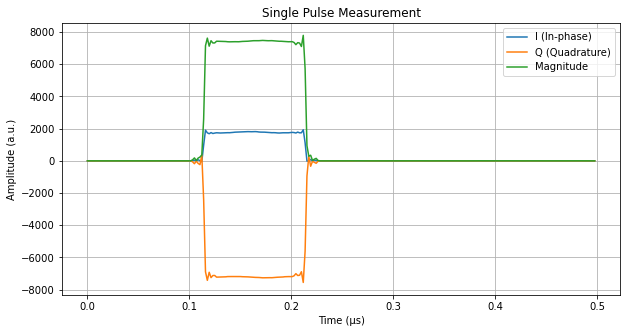

In [4]:
class SinglePulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        # Declare the generator and readout channels
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)  # nqz=1 means no frequency folding
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a constant pulse (no envelope shaping)
        self.add_pulse(
            ch=cfg['gen_ch'],
            name="my_pulse",
            style="const",           # Constant amplitude
            freq=cfg['freq'],        # Frequency in MHz
            length=cfg['pulse_len'], # Duration in microseconds
            phase=cfg['phase'],      # Phase in degrees
            gain=cfg['gain']         # Amplitude (0 to 1)
        )

        # Configure the readout
        self.add_readoutconfig(
            ch=cfg['ro_ch'],
            name="my_ro",
            freq=cfg['freq'],
            gen_ch=cfg['gen_ch']
        )
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        # Play the pulse at time t=0
        self.pulse(ch=cfg['gen_ch'], name="my_pulse", t=0)
        # Trigger the readout
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

# Configure the experiment
config = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,          # MHz
    'pulse_len': 0.1,       # microseconds
    'phase': 0,             # degrees
    'gain': 1.0,            # full amplitude
    'trig_time': 0.2,       # microseconds (when to start readout)
    'ro_len': 0.5           # microseconds (readout duration)
}

# Create and run the program
prog = SinglePulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# Acquire data (decimated mode gives IQ traces vs time)
iq_data = prog.acquire_decimated(soc, rounds=10)  # 10 averages
time_axis = prog.get_time_axis(ro_index=0)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(time_axis, iq_data[0][:,0], label='I (In-phase)')
plt.plot(time_axis, iq_data[0][:,1], label='Q (Quadrature)')
plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Single Pulse Measurement')
plt.grid(True)
plt.show()

**Explanation of the cell:**
- `declare_gen()` and `declare_readout()` tell the tProc which hardware resources we'll use
- `add_pulse()` defines a pulse with its parameters. A constant pulse (`style="const"`) has flat amplitude.
- In `_body()`, `pulse()` schedules the pulse, and `trigger()` starts the readout acquisition
- `acquire_decimated()` returns averaged IQ data. The `rounds` parameter controls how many times the entire experiment is repeated for averaging.

## 4. Multiple Pulses in One Sequence

You can define many pulses in `_initialize()` and play them in any order.

  0%|          | 0/10 [00:00<?, ?it/s]

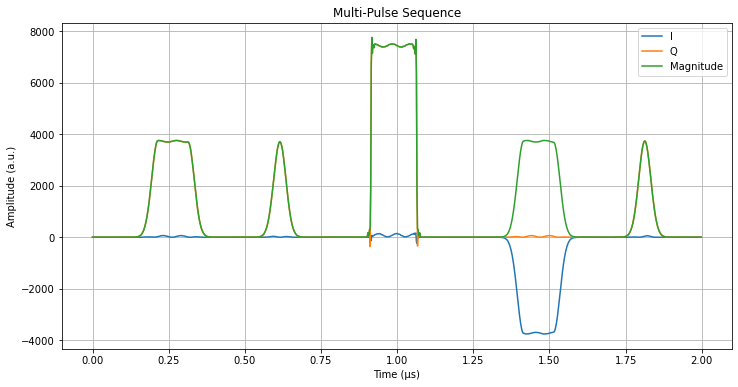

In [5]:
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])

        # Define a Gaussian envelope
        ramp_len = 0.2
        self.add_gauss(
            ch=cfg['gen_ch'],
            name="gauss_env",
            sigma=ramp_len/10,
            length=ramp_len,
            even_length=True
        )

        # Define different pulse types
        # Flat-top pulse (Gaussian rise/fall, constant middle)
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_flattop",
            style="flat_top", envelope="gauss_env",
            freq=cfg['freq'], length=0.1, phase=0, gain=1.0
        )

        # Gaussian pulse
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_gauss",
            style="arb", envelope="gauss_env",
            freq=cfg['freq'], phase=0, gain=1.0
        )

        # Constant pulse
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_const",
            style="const",
            freq=cfg['freq'], length=0.15, phase=0, gain=1.0
        )

        # Flat-top pulse with 90-degree phase
        self.add_pulse(
            ch=cfg['gen_ch'], name="p_flattop_90",
            style="flat_top", envelope="gauss_env",
            freq=cfg['freq'], length=0.1, phase=90, gain=1.0
        )

        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro", freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)

    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        # Sequence of pulses at different times (microseconds)
        self.pulse(ch=cfg['gen_ch'], name="p_flattop", t=0)
        self.pulse(ch=cfg['gen_ch'], name="p_gauss", t=0.4)
        self.pulse(ch=cfg['gen_ch'], name="p_const", t=0.8)
        self.pulse(ch=cfg['gen_ch'], name="p_flattop_90", t=1.2)
        self.pulse(ch=cfg['gen_ch'], name="p_gauss", t=1.6)

# Run the multi-pulse sequence
config['ro_len'] = 2.0  # Longer readout to capture all pulses
prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
iq_data = prog.acquire_decimated(soc, rounds=10)
time_axis = prog.get_time_axis(ro_index=0)

plt.figure(figsize=(12, 6))
plt.plot(time_axis, iq_data[0][:,0], label='I')
plt.plot(time_axis, iq_data[0][:,1], label='Q')
plt.plot(time_axis, np.abs(iq_data[0].dot([1,1j])), label='Magnitude')
plt.legend()
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude (a.u.)')
plt.title('Multi-Pulse Sequence')
plt.grid(True)
plt.show()

**Key observations from this example:**
- Once a pulse is defined, it can be reused multiple times (`p_gauss` appears twice)
- Different pulse styles serve different purposes: `const` for square pulses, `arb` for shaped pulses, `flat_top` for shaped pulses with a constant top
- The `even_length=True` parameter ensures the envelope has an even number of samples, which is required for some operations

## 5. Inspecting Your Program

You can print the program to see what the tProc will execute:

In [6]:
print(prog)

macros:
	WriteReg(dst='s_core_w1', src=0)
	ConfigReadout(ch=0, name='my_ro', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff90a81330>}, t_regs={'t': 0})
	Delay(t=1.0, auto=True, gens=True, ros=True, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff90a812a0>}, t_regs={'t': 492})
	OpenLoop(n=1, name='reps')
	Trigger(ros=[0], tts=[], pins=[0], t=0.2, width=0.020345052083333336, ddr4=True, mr=False, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff90a810c0>, 'width': <qick.asm_v2.QickParam object at 0xffff90a812d0>}, t_regs={'t': 98, 'width': 10}, outdict=defaultdict(<class 'int'>, {}), trigset={0, 3, 4})
	Pulse(ch=0, name='p_flattop', t=0, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff90a811e0>}, t_regs={'t': 0})
	Pulse(ch=0, name='p_gauss', t=0.4, tag=None, t_params={'t': <qick.asm_v2.QickParam object at 0xffff90a81030>}, t_regs={'t': 197})
	Pulse(ch=0, name='p_const', t=0.8, tag=None, t_params={'t': <qick.asm_v2.QickP

**Explanation:** This prints the compiled program in three sections:
1. **macros:** High-level operations (pulse definitions, loops, triggers)
2. **registers:** Allocated data registers
3. **pulses:** Defined waveforms with their parameters
4. **expanded ASM:** The actual assembly code that runs on the tProc

Understanding this output becomes important when debugging complex sequences.

## 6. Summary

You have learned:
- The structure of a tProc v2 program (`_initialize` vs `_body`)
- How to define and play pulses of different styles (const, arb, flat_top)
- How to trigger readout and acquire IQ data
- How to inspect the generated assembly code

**Next steps:** Proceed to [``02_Parameter_Sweeps.ipynb``](./02_Parameter_Sweeps.ipynb) to learn how to automate parameter variation and create 2D scans.